In [4]:
import os, yaml, sys
import numpy as np
import torch
import h5py
from torchvision import models
from scipy.spatial.distance import euclidean,squareform, pdist
import matplotlib.pyplot as plt
from scipy.io import loadmat
from numba import njit
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import get_device, print_wise, index_gram
device = get_device()

10:12:02 - device being used: mps


In [2]:
from scipy.stats import rankdata
def minmax_transform(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))


def rank_transform(data):
    return rankdata(data)

In [ ]:
def gt_transform(data, gt_type="lu", **kwargs):
    data = minmax_transform(rank_transform(data))
    gtx = None
    if gt_type == "lu":
        l = kwargs.get("l", 0.2)
        u = kwargs.get("u", 0.8)
        gt_min = np.quantile(data, l)
        gt_max = np.quantile(data, u)
        gtx = data.copy()
        gtx[data < gt_min] = 0
        gtx[(data >= gt_min) & (data <= gt_max)] = (
            data[(data >= gt_min) & (data <= gt_max)] - gt_min
        ) / (gt_max - gt_min)
        gtx[data > gt_max] = 1
    elif gt_type == "sigmoid":
        alpha = kwargs.get("alpha", 10)
        beta = kwargs.get("beta", 0.5)
        gtx = 1 / (1 + np.exp(-(data - beta) * alpha))
    else:
        print("please specify the right gt_type")
    return gtx

# ISOMAP

In [ ]:
from general_utils.utils import create_RDM, double_centering
from scipy.linalg import eigh


# TODO:
# - find a way to avoid having infinites (iterative increase of kNN or of distance cutoff?)
# - put it in src and test its informativeness vs e.g. PCA on the swiss-roll
@njit
def floyd_warshall_numba(G):
    N = G.shape[0]
    for k in range(N):
        for i in range(N):
            for j in range(N):
                new = G[i, k] + G[k, j]
                if new < G[i, j]:
                    G[i, j] = new
    return G
# EOF

class isomap():
    def __init__(self, isomap_type: str, distance_cutoff, distance_metric='euclidean', mode='auto'): # distance cutoff can be either a float (if isomap_type == 'eps') or an int (if isomap_type=='kNN')
        self.isomap_type = isomap_type
        self.distance_cutoff = distance_cutoff
        self.distance_metric = distance_metric
        if self.isomap_type == 'kNN':
            if not isinstance(distance_cutoff, int):
                raise TypeError(f"For 'kNN' isomap_type, distance_cutoff must be an int, got {type(distance_cutoff).__name__}")
            # end if self.isomap_type == 'kNN':
        # end if not isinstance(distance_cutoff, int):
    # EOF

    # --- GETTERS ---
    def get_G(self):
        return self.G
    # EOF

    def get_distance_cutoff(self):
        return self.distance_cutoff
    # EOF
    # --- SETTERS ---
    def set_G(self, G):
        self.G = G
    # EOF

    def set_distance_cutoff(self, distance_cutoff):
        self.distance_cutoff = distance_cutoff
    # EOF

    def compute_NNs(self):
        self.G = squareform(self.G)
        self.N = self.G.shape[0] # include it also in the setter
        np.fill_diagonal(self.G, np.inf)
        order = np.argsort(self.G, axis=0)
        kmins = order[:self.distance_cutoff, :]
        # setattr(self, f"kmins_idx", kmins) 
        return kmins
    # EOF
    
    def double_centering(self):
        self.G = double_centering(self.G)


    def init_gram(self, data: np.ndarray):    
        self.G = create_RDM(data, self.distance_metric)
        if self.isomap_type == 'eps':
            self.G[self.G >= self.distance_cutoff] = float("inf")
            self.G = squareform(self.G)
        elif self.isomap_type == 'kNN':
            kmins = self.compute_NNs() # kmins is a (k, N) matrix, so we loop over the columns
            G_temp = np.full_like(self.G, np.inf)  # fill everything with inf
            G_temp[kmins, np.arange(self.G.shape[1])] = self.G[kmins, np.arange(self.G.shape[1])] # substitutes only the values of the kNNs
            np.fill_diagonal(self.G, 0.0)
            self.G = G_temp
        # end if self.isomap_type == 'eps':
    # EOF 
    
    def war_floyd(self) -> np.array:
        self.G = floyd_warshall_numba(self.G)
        if np.any(np.isinf(self.G)): #ADD see how to fix this inf thing (like clipping between 0 and 2)
            n_inf = np.isinf(self.G).sum()
            inf_per_row = np.isinf(self.G).sum(axis=1)
            
            np.where(inf_per_row > 0)
            raise ValueError(
                f"The distance cutoff wasn't high enough to connect all the points of the graph, found still {n_inf/2} unconnected edges, \n max {inf_per_row.max()} \n avg: {inf_per_row.mean()}"
            )
        self.double_centering()
        return self.G
    # EOF

    def get_eig(self, n=None):
        evals, evecs = eigh(self.G)
        evals, evecs =  evals[::-1], evecs[:,::-1]
        self.evals_cumsum = np.cumsum(evals)
        self.evals, self.evecs = evals[:n], evecs[:,:n]
        return self.evecs, self.evals
    # EOF

    def variance_explained(self, d: np.ndarray) -> float:
        var = self.evals[d] / self.evals_cumsum[-1] 
        return var
    # EOF

    def get_embeddings(self, d_list: list):
        tot_embeddings = []
        for d in d_list:
            embedding_d = np.sqrt(self.evals[d]) * self.evecs[:, d]
            tot_embeddings.append(embedding_d)
        tot_embeddings = np.stack(tot_embeddings, axis=0)
        return tot_embeddings
    # EOF


        

In [46]:
iso_obj = isomap("kNN", 10)
iso_obj.init_gram(X.T)
iso_obj.war_floyd()


array([[ 23.39512088,  -9.66396991, -15.50294816, ...,   0.18058491,
        -15.52928389,  19.16842183],
       [ -9.93552686,  12.69149673,   7.41675469, ...,  -1.84707718,
          7.48946465,  -9.15876702],
       [-15.40103947,   7.34142426,  31.68164876, ...,  -7.26604428,
         32.49994075, -14.71306182],
       ...,
       [  0.20713408,  -1.7484205 ,  -7.40387569, ...,   8.0661291 ,
         -7.49000356,   0.15725774],
       [-15.44460958,   7.29785415,  32.54249851, ...,  -7.30961439,
         33.29885033, -14.75663193],
       [ 19.05790541,  -9.0290292 , -14.65892056, ...,   0.15657842,
        -14.5862106 ,  21.39559788]])

In [47]:
evals, evecs = iso_obj.get_eig()
X_d = iso_obj.get_embeddings(np.arange(3))

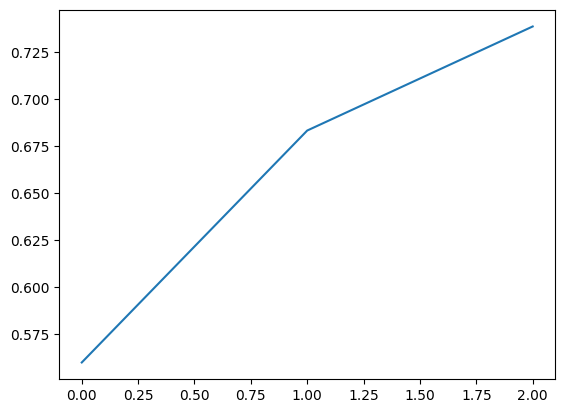

In [48]:
plt.plot(iso_obj.evals_cumsum[:3]/iso_obj.evals_cumsum[-1])

In [7]:
import numpy as np

def swiss_roll(n=2000, noise=0.0):
    t = 3 * np.pi / 2 * (1 + 2 * np.random.rand(n))
    h = 21 * np.random.rand(n)

    x = t * np.cos(t)
    y = h
    z = t * np.sin(t)

    X = np.vstack((x, y, z)).T
    X += noise * np.random.randn(*X.shape)
    return X, t

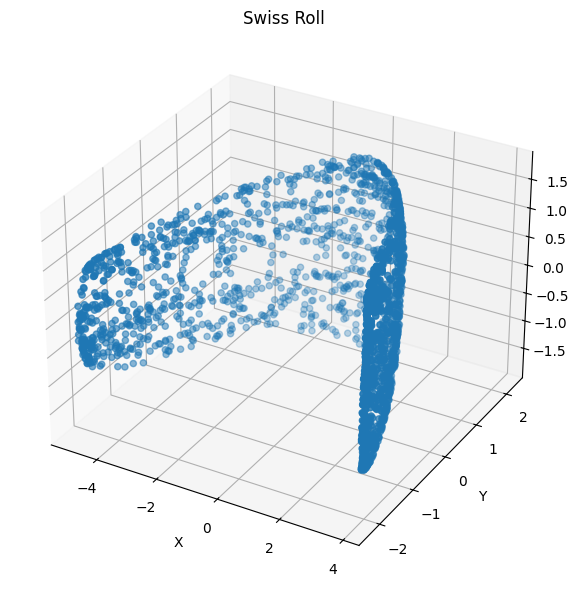

In [49]:
# plot
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X_d[0,:], X_d[1,:], X_d[2,:]
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Swiss Roll")

# plt.colorbar(sc, ax=ax, label="Intrinsic parameter t")
plt.tight_layout()
plt.show()

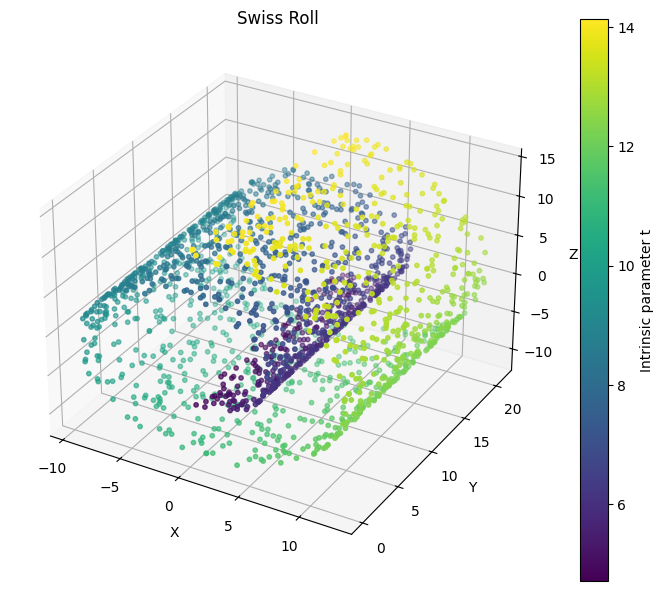

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import make_swiss_roll 
X, t = make_swiss_roll(n_samples=2000)
# generate data
# X, t = swiss_roll(n=1000, noise=0.0)

# plot
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X[:, 0], X[:, 1], X[:, 2],
    c=t, cmap="viridis", s=10
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Swiss Roll")

plt.colorbar(sc, ax=ax, label="Intrinsic parameter t")
plt.tight_layout()
plt.show()

In [9]:
a = np.random.randn(5,5)
mins = np.array([3, 1, 4, 3,2])
b = np.full_like(a, np.inf)  # fill everything with inf
b[mins, np.arange(a.shape[1])] = a[mins, np.arange(a.shape[1])]

In [ ]:
print(a)


[[-0.0647198   1.59349968  0.90509062 -0.10021763 -1.33129071]
 [-1.57440408  0.36630671  0.02498037 -2.44527274 -2.4210432 ]
 [ 0.50552772 -0.80813019  0.19839662 -1.15632521  0.07039222]
 [-0.40600581  0.20435936  0.70299226 -0.79107316  0.01035437]
 [-0.45757637 -0.5159563  -0.37964139 -0.04369212 -0.06836361]]


array([[-1.33129071, -0.10021763,  0.90509062,  1.59349968, -0.0647198 ],
       [-2.4210432 , -2.44527274,  0.02498037,  0.36630671, -1.57440408],
       [ 0.07039222, -1.15632521,  0.19839662, -0.80813019,  0.50552772],
       [ 0.01035437, -0.79107316,  0.70299226,  0.20435936, -0.40600581],
       [-0.06836361, -0.04369212, -0.37964139, -0.5159563 , -0.45757637]])

In [8]:
a = np.arange(5)
a.cumsum()

array([ 0,  1,  3,  6, 10])

In [ ]:
import numpy as np
from numba import njit
from scipy.linalg import eigh

"""
war_floyd_init
Initializes the Gram matrix for further warshall-floyd. It first computes the distance matrix.
Then, it substitues with inifinite all the entries that are above a distance_cutoff.
pdist assumes my data matrix is (NxD), datapoints along the rows
Input:
- data: np.array -> NxD data matrix
- distance_cutoff: float -> distance above which we consider our data not connected anymore

Output:
- G: np.array -> NxN Gram matrix
"""


def war_floyd_init(data: np.array, distance_cutoff: float) -> np.array:
    dist = pdist(data, metric="euclidean")
    dist_mat = squareform(dist)
    G = np.copy(dist_mat)
    G[G >= distance_cutoff] = float("inf")
    return G

"""
war_floyd
Warshall-Floyd algorithm, given an already initialized Gram matrix. It is a way to establish the 
distances between points by following the embedding manifold profile. If a distance is smaller by 
passing through another point, you substitute it. At the end, the Gram matrix has in its entries 
the shortest distances between the points. war-floyd_init is not embedded in this function because 
otherwise I wouldn't be able to use jit.
Input:
- G: np.array -> the Gram matrix already initialized

Output:
- G: np.array -> the updated Gram matrix 
"""


@njit
def war_floyd(G: np.array) -> np.array:
    N = len(G)
    G_new = np.copy(G)
    # algorithm implementation
    for k in range(N):
        for i in range(N):
            for j in range(N):
                if G_new[i, j] > (
                    G_new[i, k] + G_new[k, j]
                ):  # if the distance between i and j is shorted when passing through k
                    G_new[i, j] = G_new[i, k] + G_new[k, j]  # update the entry
                # end if
            # end for j
    # end for i
    # end for k
    if np.any(np.isinf(G)):
        raise ValueError(
            "The distance cutoff wasn't high enough to connect all the points of the graph"
        )
    return G_new


# EOF



In [ ]:
"""
isomap_wrapper
Function to wrap up all the isomap process. First computes the Gram matrix with Warshall-Floyd, 
then extracts the eigenvalues and the associated eigenvectors and finally plots
the spectrum and the data in two components (PC1-PC2).
INPUT:
- data: np.array -> (NxD) Data matrix, requires points in the rows and features in the columns
- dc -> distance cutoff in the warshall-floyd initialization
- title: str -> for the title of the plots
OUTPUT
- evals: np.array, evec: np.array -> the eigenvalues (Dx1) and associated eigenvectors 
(DxD, evecs are column vectors) respectively, sorted in increasing order of eigenvalues
"""


def isomap_wrapper(data: np.array, dc, title: str, path2save=None):
    G_init = war_floyd_init(
        data, dc
    )  # initializes the distance matrix for the warshall-floyd algorithm
    G = war_floyd(G_init)
    G_dcnt = double_centering(G, 1e-5)
    evals, evec = eigh(G_dcnt)
    N = len(G)
    plt.scatter(np.arange(N), evals)
    if path2save is not None:
        plt.title("isomap eigenvalues spectrum")
        plt.savefig(f"{path2save}/{title}_isomap_spectrum.png")
    plt.show()
    # computes the explained variance
    var_explained = variance_explained(evals, 2)
    plot_isomap_PC1_PC2(data, evec, evals, title, var_explained, path2save)
    return evals
